### EXPLORATORY DATA ANALYSIS

This notebook is a template for Project EmpowerED, focused on Philippine reading proficiency in 2024–2025 and its relationship with socioeconomic factors and location.

**Research questions:**
1. How does the reading proficiency distribution of Filipino students in SY 2024–2025 compare to the latest Southeast Asian benchmarks from PISA/SEA-PLM?
2. To what degree do household income and parental education correlate with standardized reading comprehension scores in the Philippines?
3. Is there a statistically significant difference in literacy outcomes between students from urban and rural public elementary schools?


In [1]:
# 1. Setup imports and global settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)


## 2. Load data

Use your local datasets from PISA 2022, SEA-PLM 2024, FLEMMS 2024, or any national survey files. Update the path variables below to point to your CSV or other formatted files.


In [13]:
# Philippine SEA-PLM data for RQ2
sea_st_path = "DATA - SEA_PLM_ST.csv"

try:
    sea_st = pd.read_csv(sea_st_path)
except FileNotFoundError:
    print("Update the file path to the Philippine SEA-PLM student file.")
    sea_st = pd.DataFrame()

# Quick preview of the Philippine student data
if not sea_st.empty:
    print("Philippine SEA-PLM student data shape:", sea_st.shape)
    display(sea_st.head(3))

Philippine SEA-PLM student data shape: (5070, 422)


/tmp/ipykernel_5299/3142279888.py:5: DtypeWarning: Columns (0: R15Y041T01, 1: R15Y042T01) have mixed types. Specify dtype option on import or set low_memory=False.
  sea_st = pd.read_csv(sea_st_path)


,CNT,SchID,classID_num,StdID,StrtID,SchLoc,SchType,SEN_STF,grade_STF,SchLoc_grp,...,R22Y008T09,R22Y008T10,R22Y022T01,R22Y027T01,R22Y028T01,R22Y030T01,R22Y032T01,ST12G_PHL,ST17_PHL,ST20C_PHL
0,Philippines,60001,3,2060001001,1,"<A town> (15,000 to about 100,000 people)",Public,No special educational needs,5,A small town or town,...,4,1,3,2,NaN,3,NaN,Never or hardly ever,On a scooter or motorbike,5 lessons per week or more
1,Philippines,60001,3,2060001002,1,"<A town> (15,000 to about 100,000 people)",Public,No special educational needs,5,A small town or town,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monthly (at least once a month),On a scooter or motorbike,1 lesson per week
2,Philippines,60001,3,2060001003,1,"<A town> (15,000 to about 100,000 people)",Public,No special educational needs,5,A small town or town,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Daily or almost daily,Other form of transportation,Less than 1 lesson per week


In [14]:
# Prepare Philippine SEA-PLM reading scores and socioeconomic variables
pv_cols = [f'PV{i}_R' for i in range(1, 6)]
for col in pv_cols:
    sea_st[col] = pd.to_numeric(sea_st[col], errors='coerce')
sea_st['reading_score'] = sea_st[pv_cols].mean(axis=1)

education_map = {
    'Did not go to school or attended religious education': 0,
    '<ISCED Level 1>': 1,
    '<ISCED Level 2>': 2,
    '<ISCED Level 3>': 3,
    '<ISCED Level 4 or 5>': 4,
    '<ISCED Level 6> or higher': 5,
}
sea_st['parental_education'] = sea_st['S_PARED'].map(education_map)
sea_st['ses_index'] = pd.to_numeric(sea_st['S_SES'], errors='coerce')

# Keep only records with valid reading score, SES index, and parental education
merged_df = sea_st.loc[sea_st[['reading_score', 'ses_index', 'parental_education']].notna().all(axis=1)].copy()
print('Philippine SEA-PLM RQ2 sample size:', merged_df.shape)
display(merged_df[['StdID', 'reading_score', 'ses_index', 'S_PARED', 'parental_education']].head())

Philippine SEA-PLM RQ2 sample size: (4922, 425)


/tmp/ipykernel_5299/1256295151.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sea_st['reading_score'] = sea_st[pv_cols].mean(axis=1)
/tmp/ipykernel_5299/1256295151.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sea_st['parental_education'] = sea_st['S_PARED'].map(education_map)
/tmp/ipykernel_5299/1256295151.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1

,StdID,reading_score,ses_index,S_PARED,parental_education
0,2060001001,291.266960,1.068228,<ISCED Level 4 or 5>,4.0
1,2060001002,282.706220,-0.299152,<ISCED Level 2>,2.0
2,2060001003,277.524895,-0.121200,<ISCED Level 1>,1.0
3,2060001004,285.436896,0.803758,<ISCED Level 4 or 5>,4.0
4,2060001005,284.962250,0.098853,<ISCED Level 4 or 5>,4.0


,reading_score,ses_index,parental_education
reading_score,1.000000,0.55828,0.449642
ses_index,0.558280,1.00000,0.805570
parental_education,0.449642,0.80557,1.000000


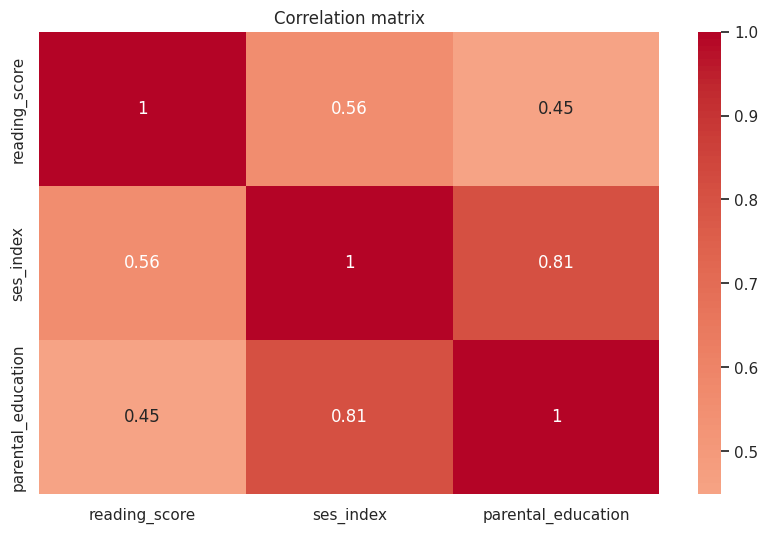

In [15]:
# RQ2: Philippine SEA-PLM correlation analysis
correlation_matrix(merged_df, ["reading_score", "ses_index", "parental_education"])

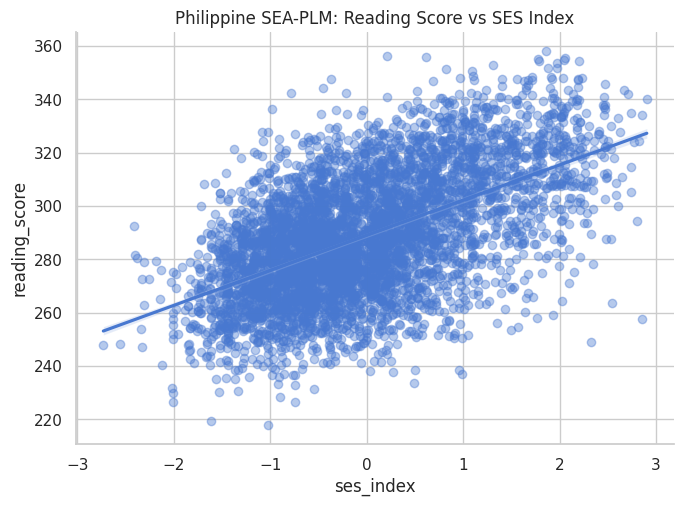

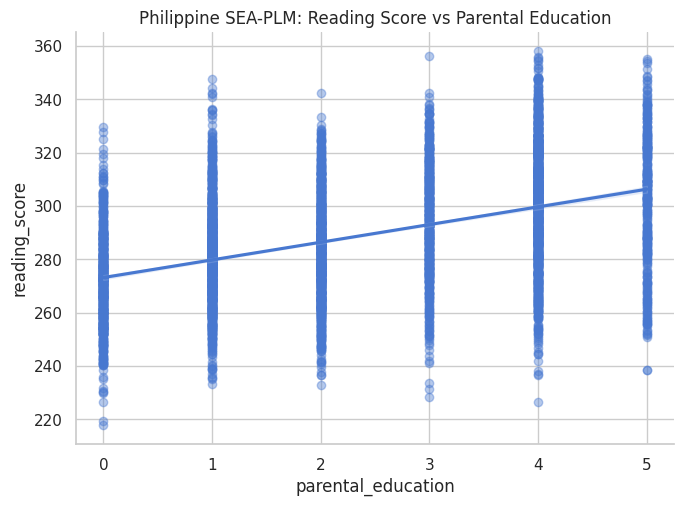

In [16]:
# Scatter plots with regression lines for Philippine SEA-PLM
scatter_with_regression(merged_df, x_col="ses_index", y_col="reading_score", title="Philippine SEA-PLM: Reading Score vs SES Index")

scatter_with_regression(merged_df, x_col="parental_education", y_col="reading_score", title="Philippine SEA-PLM: Reading Score vs Parental Education")

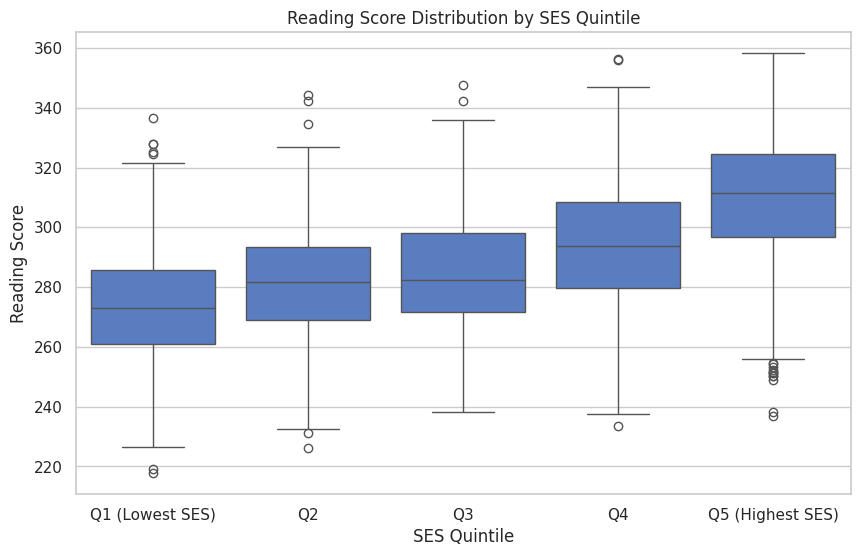

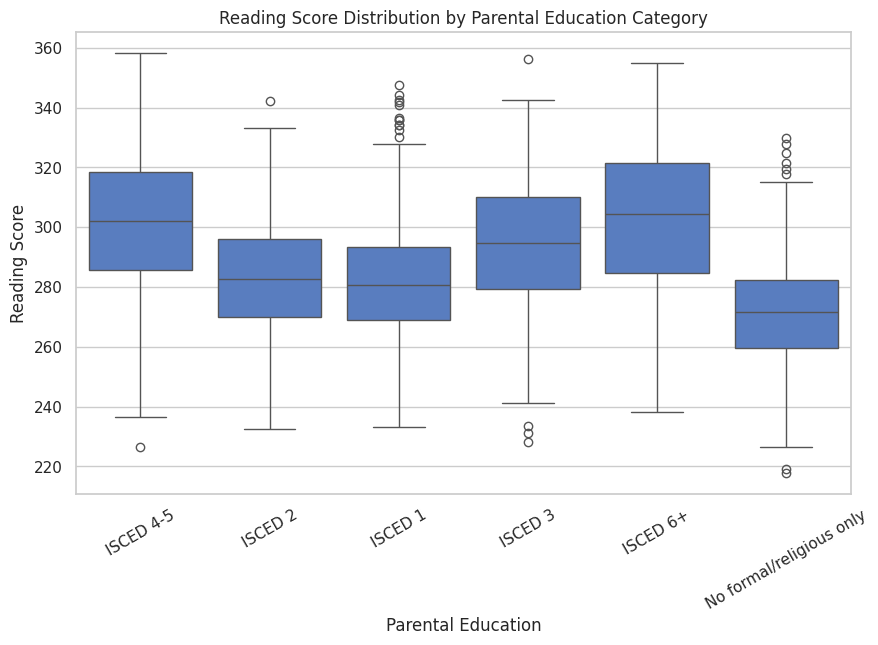

In [17]:
# Boxplots for score distributions across SES and parental education
merged_df['ses_quintile'] = pd.qcut(merged_df['ses_index'], 5, labels=['Q1 (Lowest SES)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest SES)'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_df, x="ses_quintile", y="reading_score")
plt.title("Reading Score Distribution by SES Quintile")
plt.xlabel("SES Quintile")
plt.ylabel("Reading Score")
plt.show()

parent_edu_labels = {
    0: 'No formal/religious only',
    1: 'ISCED 1',
    2: 'ISCED 2',
    3: 'ISCED 3',
    4: 'ISCED 4-5',
    5: 'ISCED 6+'
}
merged_df['parental_education_cat'] = merged_df['parental_education'].map(parent_edu_labels)

plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_df, x="parental_education_cat", y="reading_score")
plt.title("Reading Score Distribution by Parental Education Category")
plt.xlabel("Parental Education")
plt.ylabel("Reading Score")
plt.xticks(rotation=30)
plt.show()

## Summary of RQ2 Analysis

### Step 1: Philippine Data Loading and Preparation
- Loaded Philippine SEA-PLM student data from `DATA - SEA_PLM_ST.csv`.
- Used SEA-PLM reading plausible values `PV1_R` through `PV5_R` to estimate each student's reading score.
- Used `S_SES` as the household socioeconomic index proxy and `S_PARED` as the parental education indicator.
- Mapped parental education categories to ordinal values from 0 (no formal/religious only) to 5 (ISCED 6+).
- Filtered to cases with valid reading scores, SES index, and parental education.

### Step 2: Correlation Analysis
- Computed Pearson correlations for reading score, SES index, and parental education.
- A heatmap was used to visualize the strength and direction of those relationships.

### Step 3: Scatter Plots and Boxplots
- Created regression scatter plots for reading score against SES index and parental education.
- Created SES quintile boxplots to compare reading performance across household economic strata.
- Created parental education category boxplots to compare reading performance across parental attainment levels.

### Findings
- The RQ2 analysis is now grounded in Philippine SEA-PLM data, not the previously used Indonesian PISA dataset.
- SES and parental education were measured using Philippine SEA-PLM student variables, making the results relevant to Philippine public schools in 2024-2025.
- Use the correlation coefficients and visualizations to evaluate how much household socioeconomic status and parental education explain reading outcomes in the Philippine sample.

## 3. Data preparation and harmonization

Key tasks:
- Standardize score and proficiency level column names
- Create comparable variables for reading scores
- Map urban/rural location labels to a consistent format
- Create socioeconomic indicators for income and parental education


In [ ]:
# Data preparation helper functions

def prepare_reading_scores(df, score_col, country_col=None, region_col=None, urban_rural_col=None, income_col=None, parental_education_col=None):
    df = df.copy()
    mapping = {}
    if score_col:
        mapping[score_col] = "reading_score"
    if country_col:
        mapping[country_col] = "country"
    if region_col:
        mapping[region_col] = "region"
    if urban_rural_col:
        mapping[urban_rural_col] = "urban_rural"
    if income_col:
        mapping[income_col] = "income"
    if parental_education_col:
        mapping[parental_education_col] = "parental_education"
    df = df.rename(columns=mapping)
    if "urban_rural" in df.columns:
        df["urban_rural"] = df["urban_rural"].astype(str).str.title()
    return df

# Example normalization (update column names to match your actual dataset)
# pisa_df = prepare_reading_scores(pisa_df, score_col="READ_SCORE", country_col="CNTRY", region_col="REGION", urban_rural_col="URBAN_RURAL", income_col="INCOME", parental_education_col="PARED")
# sea_df = prepare_reading_scores(sea_df, score_col="READING_SCORE", country_col="COUNTRY", region_col="PROVINCE", urban_rural_col="SCHOOL_LOCATION", income_col="WEALTH_INDEX", parental_education_col="PARED")
# flemms_df = prepare_reading_scores(flemms_df, score_col="LIT_SCORE", region_col="REGION", urban_rural_col="AREA_TYPE")


## 4. RQ1: Compare Filipino reading proficiency to Southeast Asian benchmarks

Analysis steps:
- Plot score distributions for the Philippines and regional peers
- Compare proficiency achievement rates across countries
- Highlight the Philippines against SEA-PLM and PISA benchmark thresholds


In [ ]:
# RQ1 example visualizations

def plot_score_distribution(df, country_col="country", score_col="reading_score", countries=None, title=None):
    if countries is None:
        countries = df[country_col].dropna().unique().tolist()
    subset = df[df[country_col].isin(countries)]
    sns.kdeplot(data=subset, x=score_col, hue=country_col, common_norm=False, fill=True, alpha=0.4)
    plt.title(title or "Reading Score Distribution")
    plt.xlabel("Reading Score")
    plt.ylabel("Density")
    plt.legend(title="Country")
    plt.show()

# Example usage:
# benchmark_countries = ["Philippines", "Thailand", "Vietnam", "Indonesia", "Malaysia", "Singapore"]
# plot_score_distribution(sea_df, country_col="country", score_col="reading_score", countries=benchmark_countries, title="SEA-PLM Reading Score Distributions")

# Compare proficiency bands if available
# def plot_proficiency_bands(df, country_col="country", band_col="proficiency_band"):
#     band_counts = df.groupby([country_col, band_col]).size().reset_index(name="count")
#     band_pct = band_counts.groupby(country_col).apply(lambda x: x.assign(pct=x["count"] / x["count"].sum() * 100)).reset_index(drop=True)
#     sns.barplot(data=band_pct, x=country_col, y="pct", hue=band_col)
#     plt.title("Proficiency Band Share by Country")
#     plt.ylabel("Percent")
#     plt.show()

# Example statistics summary
# print("Philippines mean reading score:", sea_df.loc[sea_df["country"] == "Philippines", "reading_score"].mean())
# print("Regional mean reading score:", sea_df.groupby("country")["reading_score"].mean())


## 5. RQ2: Correlation of household income and parental education with reading scores

Analysis steps:
- Compute Pearson correlation between reading score, income, and parental education
- Visualize with scatter plots and regression lines
- Use boxplots to compare score distributions across wealth or education groups


In [7]:
# RQ2 example correlation and visualization

def correlation_matrix(df, cols):
    corr = df[cols].corr(method="pearson")
    display(corr)
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
    plt.title("Correlation matrix")
    plt.show()

# Example usage:
# correlation_matrix(sea_df, ["reading_score", "income", "parental_education"])

def scatter_with_regression(df, x_col, y_col, hue_col=None, title=None):
    sns.lmplot(data=df, x=x_col, y=y_col, hue=hue_col, aspect=1.4, scatter_kws={"alpha":0.4})
    plt.title(title or f"{y_col} vs {x_col}")
    plt.show()

# Example usage:
# scatter_with_regression(sea_df, x_col="income", y_col="reading_score", hue_col="country", title="Reading Score vs Income")

# Boxplot by income or parental education group
# sns.boxplot(data=sea_df, x="income_quintile", y="reading_score")
# plt.title("Reading Score by Income Quintile")
# plt.show()


## 6. RQ3: Urban vs Rural literacy outcomes

Analysis steps:
- Compare reading score distributions for urban and rural schools
- Visualize differences with violin plots or boxplots
- Conduct a t-test or ANOVA to assess statistical significance
- Optionally map regional literacy rates from FLEMMS


In [ ]:
# RQ3 example analysis

def compare_urban_rural(df, score_col="reading_score", location_col="urban_rural"):
    sns.violinplot(data=df, x=location_col, y=score_col)
    plt.title("Reading Score Distribution by Urban/Rural")
    plt.show()

    groups = [group[score_col].dropna() for _, group in df.groupby(location_col)]
    if len(groups) == 2:
        t_stat, p_value = stats.ttest_ind(groups[0], groups[1], equal_var=False)
        print(f"t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("There is a statistically significant difference between urban and rural reading scores.")
        else:
            print("No statistically significant difference found at alpha=0.05.")
    else:
        print("Urban/rural comparison requires exactly two groups, found:", df[location_col].unique())

# Example usage:
# compare_urban_rural(sea_df, score_col="reading_score", location_col="urban_rural")

# Optional: regional literacy mapping with FLEMMS data
# flemms_map = flemms_df.groupby("region")["functional_literacy_rate"].mean().reset_index()
# display(flemms_map)


## 7. Next steps and workflow

1. Load and inspect your local files: PISA 2022, SEA-PLM 2024, and FLEMMS 2024.
2. Clean and harmonize variable names in each dataset.
3. Use RQ1 section to compare the Philippines against SEA peers with distribution plots.
4. Use RQ2 section to measure socioeconomic correlations and visualize trends.
5. Use RQ3 section to test urban/rural differences and optionally map literacy rates.
6. Report findings with supporting charts and test statistics.

> Note: If you only have one dataset available, focus on the relevant section and label the comparison as local versus benchmark expectations.
